In [43]:
#필요 패키지 전체 Import
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np
import tensorflow as tf
import sklearn as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_excel("salary.xlsx")
df.head()

,degree,rank,sex,year,ysdeg,salary
0,1,3,0,25,35,36350
1,1,3,0,13,22,35350
2,1,3,0,10,23,28200
3,1,3,1,7,27,26775
4,0,3,0,19,30,33696


In [ ]:
from sklearn.standardscaler import standardscaler
ss=standardscaler()

In [29]:
from sklearn.model_selection import train_test_split
y=df["salary"].values
X=df.drop("salary", axis=1).values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.6268191876883349

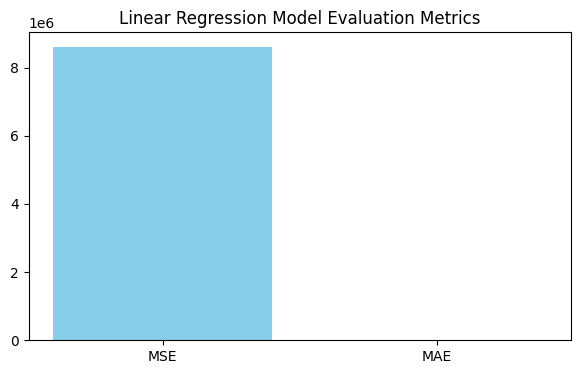

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

metrics = ['MSE', 'MAE']
scores = [mse, mae]

plt.figure(figsize=(7,4))
bars = plt.bar(metrics, scores, color=['skyblue', 'lightgreen'])
plt.title('Linear Regression Model Evaluation Metrics')
plt.show()


#### df.apply
- 각 행 및 열별 동일한 연산을 수행하기위한 메소드
- apply(func, axis =)
#### Reshaping
- 주어진 데이터를 wide form //long form으로 변환하는과정<br>
**wide form**
- 조사단위별 특성값이 여러개일때, 각 특성들을 열로 배치함<br>
**long form**
- 조사간위별 특성값이 여러개일때, 특성과 값을 반복하여 배치함
  ### Longform의 데이터 프레임 -> Wideform
  #### PIVOT(cast), 반대의 경우는 Melt라고 표현

#### Merge시 좌우 컬럼이름이 다를때는 LeftON, RightON을 통해서 지정해주기
ReadCSV중에서는 앞의 몇줄만 가져오는옵션도 있음

### Jupyter notebook에서 그래픽 결과를 Notebook 출력 셀에 보여 주는 매직커맨드(magic command)

%matplotlib inline
- 신버전에서는 보임, 혹시 안보일떄 사용하기

## Pandas에서도 간단한 그래프는 사용가능함
```py
df.plot(kind='method', x, y, ...)
df.plot.[method](column, ...)
series.plot.[method](...)
```
plot.text 활용해서 텍스트 찍는것 공부해보기

```py
sns.hist(by="그룹화할 컬럼",alpha=0.5(투명도))
plot.density() <-확률 밀도함수 추정
```

#### 수식은 "$" 사이에 집어넣음 (Latex)

# Linear Regression

추정법 : 최소제곱법 / 벌점화 추정법 (능형회귀, 라쏘회귀, 엘라스틱)

편미분(Gradient), 2차미분 (Hessian)

행렬식 구하기 ad-bc -> 연립방정식 풀이 알고리즘

제약조건이 붙은 이차함수 풀이법 : 라그랑주 승수법

P-값 (유의확률)
이진비교 -  T테스트, 다중비교 - ANOVA(분산분석) <- EDA

성능지표 : R2, MSE,  RMSE, AME,  AIC(벌점)
일반화 오차


# Classification
## Logistic clasificatation
이진분류, 다중분류(다범주, 순서형 다범주)로 나눔, 다중분류는 (A,A'), (여러개중 두개 뽑기) 로 로지스틱 표현가능함

F1, Recall, Precision, Accuracy 등의 성능평가지표 존재

손실함수 이진교차엔트로피 <- MSE,MAE 사용은 가능함, 결과가 안좋을뿐
* 회귀분석의 음의 로그가능도를 구하면 손실함수와 일치함

odds ratio <- 회귀계수

싸이클이 없는 그래프 <- 트리

# Decision Tree

* 앙상블, 랜덤포레스트, 부스팅으로 활용됨

적당한 높이 선정

> cost complexity pruning <- 비용 복잡도 가지치기<br>
Nested Subsuquence Tree <- 포함관계가 있는 트리 <- 변수선택이랑 비슷함 (Foward Selection, Backward Eleminatioin)

전체입력공간 학습 <- 글로벌 피팅
입력공간 분할 학습 <- 로컬 피팅

분류에서의 평균 <- 1일 확률 추정

- 트리의 성장절차
자식노드 추가를 통해 불순도 감소량이 최대가 되게함 (부모노드 데이터를 분리변수를 통해 분리값으로 나누어 분할하는 과정)
불순도(분류) <- 자니지수, 엔트로피지수
불순도 회귀 <- mse


랜덤포레스트 - 최소 20개 이상 합치기 <- off the shelf
부스팅 - 시퀀셜모델링
그냥 앙상블 <- 랜덤포레스트 / XG부스트 쓰자 그냥
